# Creating Rio de Janeiro City Boundary

This notebook demonstrates the process of generating a city-wide boundary polygon for Rio de Janeiro. It starts by loading individual neighborhood polygons, then dissolves them to form a single, unified city boundary. This boundary is then saved for future geospatial analyses.

This notebook will:
1.  Load the neighborhood data from the CSV you provided.
2.  Convert it into a GeoDataFrame.
3.  Dissolve the neighborhood polygons to create a single city boundary.
4.  Save this city boundary as a shapefile (and optionally other formats like GeoPackage or GeoJSON) for later use.


## 1. Setup and Imports

First, we import the necessary Python libraries.
- `os` for interacting with the file system (creating directories).
- `pandas` for data manipulation, primarily loading the CSV.
- `geopandas` for working with geospatial data.
- `shapely.wkt` for parsing Well-Known Text (WKT) geometry strings.
- `matplotlib.pyplot` for quick visualizations.

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely import wkt
from matplotlib import pyplot as plt

# Display options for pandas and geopandas (optional, for better viewing in a notebook)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Define Input and Output Paths

We define the directory paths for our input neighborhood data and the location where the generated city boundary will be saved.
The input neighborhood data is assumed to be in a CSV file as described in the problem.
The output city boundary will be saved in the 'clean' data directory, possibly in a new subfolder for organization.

In [2]:
# Input paths (as per your initial code)
input_data_directory = '../../../../../data/meteorologia/raw'
dataset_bairros = 'dados_mestres'
table_name_bairros = 'bairro' # This is the CSV file name without extension

# Output paths
output_data_directory = '../../../../../data/meteorologia/clean'
# Let's create a new subdirectory for general boundaries/limits
dataset_limites = 'limites_geograficos_rj' 
file_name_cidade = 'limite_municipio_rio_de_janeiro' # Name for the city boundary file

## 3. Load Neighborhood Data

We load the neighborhood data from the `bairro.csv` file. This file contains a `geometry_wkt` column, which stores polygon geometries in WKT format. We will convert this column into actual geometry objects and create a GeoDataFrame.

Attempting to load neighborhood data from: ../../../../../data/meteorologia/raw/dados_mestres/bairro.csv
Neighborhood CSV loaded successfully.

Original Neighborhood DataFrame (first 5 rows):


,id_bairro,nome,id_area_planejamento,id_regiao_planejamento,nome_regiao_planejamento,id_regiao_administrativa,nome_regiao_administrativa,area,perimetro,geometry_wkt,geometry
0,1,Saúde,1,1.1,Centro,1,Portuaria,3.638176e+05,2646.220568,POLYGON ((-43.181151633502964 -22.895430284304...,"POLYGON((-43.181151633503 -22.8954302843042, -..."
1,4,Caju,1,1.1,Centro,1,Portuaria,5.347481e+06,19800.522524,MULTIPOLYGON (((-43.22522241788469 -22.8746498...,MULTIPOLYGON(((-43.196711909178 -22.8872495021...
2,3,Santo Cristo,1,1.1,Centro,1,Portuaria,1.684721e+06,6743.227885,POLYGON ((-43.194498082949806 -22.903378003392...,"POLYGON((-43.1944980829498 -22.9033780033923, ..."
3,2,Gamboa,1,1.1,Centro,1,Portuaria,1.112903e+06,4612.833630,POLYGON ((-43.18791509600138 -22.8931217212322...,"POLYGON((-43.1879150960014 -22.8931217212322, ..."
4,161,Lapa,1,1.1,Centro,2,Centro,2.983258e+05,3849.181818,POLYGON ((-43.18166120770202 -22.9120798224676...,"POLYGON((-43.181661207702 -22.9120798224677, -..."



Neighborhood GeoDataFrame (first 5 rows):


,id_bairro,nome,id_area_planejamento,id_regiao_planejamento,nome_regiao_planejamento,id_regiao_administrativa,nome_regiao_administrativa,area,perimetro,geometry_wkt,geometry
0,1,Saúde,1,1.1,Centro,1,Portuaria,3.638176e+05,2646.220568,POLYGON ((-43.181151633502964 -22.895430284304...,"POLYGON ((-43.18115 -22.89543, -43.18119 -22.8..."
1,4,Caju,1,1.1,Centro,1,Portuaria,5.347481e+06,19800.522524,MULTIPOLYGON (((-43.22522241788469 -22.8746498...,"MULTIPOLYGON (((-43.22522 -22.87465, -43.22522..."
2,3,Santo Cristo,1,1.1,Centro,1,Portuaria,1.684721e+06,6743.227885,POLYGON ((-43.194498082949806 -22.903378003392...,"POLYGON ((-43.1945 -22.90338, -43.19459 -22.90..."
3,2,Gamboa,1,1.1,Centro,1,Portuaria,1.112903e+06,4612.833630,POLYGON ((-43.18791509600138 -22.8931217212322...,"POLYGON ((-43.18792 -22.89312, -43.19069 -22.8..."
4,161,Lapa,1,1.1,Centro,2,Centro,2.983258e+05,3849.181818,POLYGON ((-43.18166120770202 -22.9120798224676...,"POLYGON ((-43.18166 -22.91208, -43.18217 -22.9..."



Loaded 164 neighborhoods.
CRS of neighborhoods GeoDataFrame: EPSG:4326


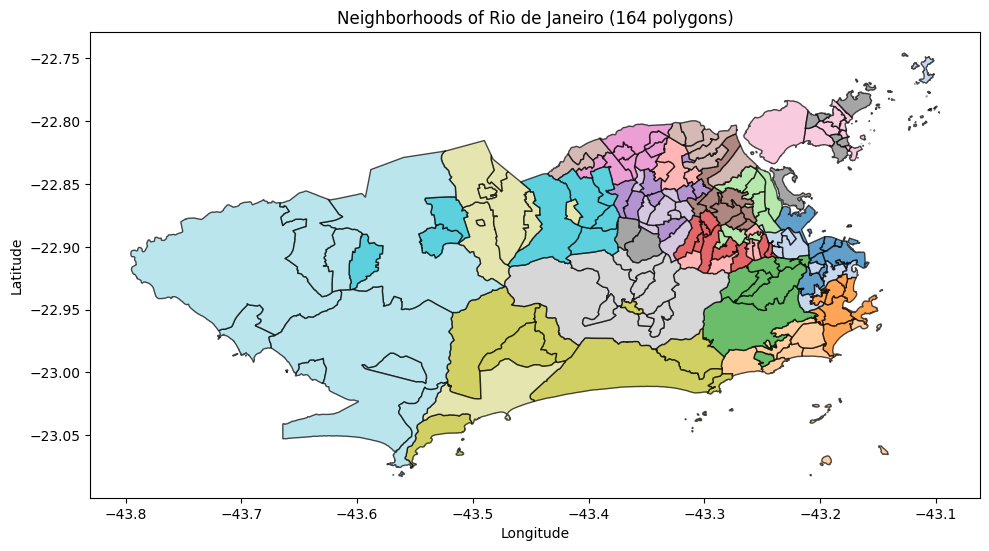

In [6]:
# Construct the full path to the neighborhood CSV file
neighborhood_csv_path = f"{input_data_directory}/{dataset_bairros}/{table_name_bairros}.csv"

print(f"Attempting to load neighborhood data from: {neighborhood_csv_path}")

try:
    bairros_df = pd.read_csv(neighborhood_csv_path)
    print("Neighborhood CSV loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at {neighborhood_csv_path}")
    print("Please ensure the path and file name are correct.")
    print("As a fallback for this demonstration, creating a dummy DataFrame...")
    # Dummy data to allow the script to run if the file is not found
    bairros_df = pd.DataFrame({
        'id_bairro': [0, 1, 2],
        'nome': ['Dummy Bairro Centro', 'Dummy Bairro Norte', 'Dummy Bairro Sul'],
        'geometry_wkt': [
            'POLYGON((-43.20 -22.90, -43.18 -22.90, -43.18 -22.92, -43.20 -22.92, -43.20 -22.90))', # Square 1
            'POLYGON((-43.20 -22.88, -43.18 -22.88, -43.18 -22.90, -43.20 -22.90, -43.20 -22.88))', # Square 2 (adjacent to 1)
            'POLYGON((-43.18 -22.92, -43.16 -22.92, -43.16 -22.94, -43.18 -22.94, -43.18 -22.92))'  # Square 3 (adjacent to 1)
        ]
    })

print('\nOriginal Neighborhood DataFrame (first 5 rows):')
display(bairros_df.head())

# Convert WKT geometry to Shapely geometry objects
# It's good practice to handle potential errors during WKT parsing
def safe_wkt_load(x):
    try:
        return wkt.loads(x)
    except Exception:
        return None

bairros_df['geometry'] = bairros_df['geometry_wkt'].apply(safe_wkt_load)

# Drop rows where geometry could not be parsed
bairros_df.dropna(subset=['geometry'], inplace=True)

# Create a GeoDataFrame
# Assuming original CRS is WGS84 (EPSG:4326) as per your initial code
bairros_gdf = gpd.GeoDataFrame(bairros_df, geometry='geometry', crs="EPSG:4326")

print('\nNeighborhood GeoDataFrame (first 5 rows):')
display(bairros_gdf.head())

# --- Basic Sanity Check and Visualization of Neighborhoods ---
if not bairros_gdf.empty:
    print(f"\nLoaded {len(bairros_gdf)} neighborhoods.")
    print(f"CRS of neighborhoods GeoDataFrame: {bairros_gdf.crs}")

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    bairros_gdf.plot(ax=ax, cmap='tab20', edgecolor='black', alpha=0.7)
    ax.set_title(f"Neighborhoods of Rio de Janeiro ({len(bairros_gdf)} polygons)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("\nNeighborhood GeoDataFrame is empty. Cannot proceed with dissolve or plotting.")

## 4. Create City Boundary via Dissolve

To obtain the overall city boundary, we dissolve all individual neighborhood polygons into a single, unified polygon. The `dissolve()` method in GeoPandas is used for this. We can create a dummy column with a constant value and dissolve by it to ensure all polygons are merged into one feature.
It's also a good practice to ensure geometries are valid before operations like dissolve, e.g., by applying a zero-width buffer.


City Boundary GeoDataFrame (after dissolve):
  city_identifier                                           geometry  \
0  Rio de Janeiro  MULTIPOLYGON (((-43.56863 -23.08168, -43.56871...   

   id_bairro   nome  id_area_planejamento  id_regiao_planejamento  \
0          1  Saúde                     1                     1.1   

  nome_regiao_planejamento  id_regiao_administrativa  \
0                   Centro                         1   

  nome_regiao_administrativa           area    perimetro  \
0                  Portuaria  363817.622559  2646.220568   

                                        geometry_wkt  
0  POLYGON ((-43.181151633502964 -22.895430284304...  
CRS of city boundary GeoDataFrame: EPSG:4326


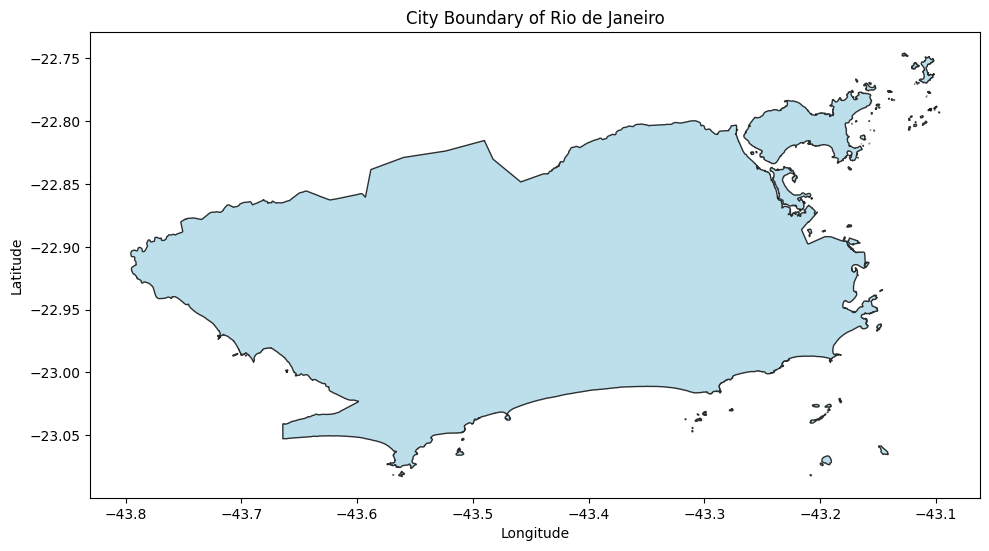

In [7]:
if not bairros_gdf.empty:
    # Ensure geometries are valid (buffer(0) is a common trick to fix minor issues)
    bairros_gdf['geometry'] = bairros_gdf.geometry.buffer(0)
    
    # Filter out any empty or invalid geometries that might have resulted from buffer(0) on bad input
    bairros_gdf = bairros_gdf[~bairros_gdf.geometry.is_empty & bairros_gdf.geometry.is_valid]

    if not bairros_gdf.empty:
        # Create a dummy column to dissolve all neighborhoods into a single feature
        bairros_gdf['city_identifier'] = 'Rio de Janeiro'
        
        # Dissolve the neighborhood polygons
        # The `aggfunc` can be used if you want to aggregate attributes, e.g., sum areas.
        # For just the boundary, we primarily need the geometry.
        # 'first' will take the first value for non-numeric columns being aggregated.
        city_boundary_gdf = bairros_gdf.dissolve(by='city_identifier', aggfunc='first')
        
        # Reset index to make 'city_identifier' a regular column (optional, but often cleaner)
        city_boundary_gdf = city_boundary_gdf.reset_index()

        print("\nCity Boundary GeoDataFrame (after dissolve):")
        print(city_boundary_gdf)
        print(f"CRS of city boundary GeoDataFrame: {city_boundary_gdf.crs}")

        # --- Visualize the City Boundary ---
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        city_boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.8)
        # Optionally, plot neighborhoods underneath for context
        # bairros_gdf.plot(ax=ax, edgecolor='gray', facecolor='none', linewidth=0.5, alpha=0.5)
        ax.set_title("City Boundary of Rio de Janeiro")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.tight_layout()
        plt.show()
    else:
        print("\nAfter cleaning, no valid neighborhood geometries remain to create a city boundary.")
        city_boundary_gdf = gpd.GeoDataFrame() # Create empty GDF to prevent later errors
else:
    print("\nCannot create city boundary because neighborhood data is empty.")
    city_boundary_gdf = gpd.GeoDataFrame() # Create empty GDF

## 5. Save City Boundary

Now, we save the generated city boundary GeoDataFrame to a file. We will save it as a Shapefile, and also demonstrate saving to GeoPackage and GeoJSON, which are often more robust alternatives.

In [8]:
if not city_boundary_gdf.empty:
    # Create the output directory if it doesn't exist
    output_limites_full_path = f'{output_data_directory}/{dataset_limites}'
    os.makedirs(output_limites_full_path, exist_ok=True)
    print(f"\nOutput directory: {output_limites_full_path}")

    # --- Save to Shapefile ---
    city_boundary_shapefile_path = f"{output_limites_full_path}/{file_name_cidade}.shp"
    try:
        # Shapefiles have limitations (e.g., column name length).
        # It's safer to select only necessary columns, or ensure names are short.
        # For a boundary, often only 'geometry' and perhaps an ID/Name are needed.
        # The 'city_identifier' column created earlier should be fine.
        city_boundary_gdf_to_save = city_boundary_gdf[['city_identifier', 'geometry']] # Or just [['geometry']]
        city_boundary_gdf_to_save.to_file(city_boundary_shapefile_path, driver='ESRI Shapefile')
        print(f"City boundary successfully saved to Shapefile: {city_boundary_shapefile_path}")
    except Exception as e:
        print(f"Error saving city boundary to Shapefile: {e}")
        print("Attempting to save only geometry...")
        try:
            city_boundary_gdf[['geometry']].to_file(city_boundary_shapefile_path, driver='ESRI Shapefile')
            print(f"City boundary (geometry only) successfully saved to Shapefile: {city_boundary_shapefile_path}")
        except Exception as e2:
            print(f"Error saving city boundary (geometry only) to Shapefile: {e2}")


    # --- Save to GeoPackage (Recommended) ---
    city_boundary_gpkg_path = f"{output_limites_full_path}/{file_name_cidade}.gpkg"
    try:
        city_boundary_gdf.to_file(city_boundary_gpkg_path, driver="GPKG")
        print(f"City boundary successfully saved to GeoPackage: {city_boundary_gpkg_path}")
    except Exception as e:
        print(f"Error saving city boundary to GeoPackage: {e}")

    # --- Save to GeoJSON ---
    city_boundary_geojson_path = f"{output_limites_full_path}/{file_name_cidade}.geojson"
    try:
        city_boundary_gdf.to_file(city_boundary_geojson_path, driver="GeoJSON")
        print(f"City boundary successfully saved to GeoJSON: {city_boundary_geojson_path}")
    except Exception as e:
        print(f"Error saving city boundary to GeoJSON: {e}")
else:
    print("\nCity boundary GeoDataFrame is empty. Nothing to save.")


Output directory: ../../../../../data/meteorologia/clean/limites_geograficos_rj
City boundary successfully saved to Shapefile: ../../../../../data/meteorologia/clean/limites_geograficos_rj/limite_municipio_rio_de_janeiro.shp
City boundary successfully saved to GeoPackage: ../../../../../data/meteorologia/clean/limites_geograficos_rj/limite_municipio_rio_de_janeiro.gpkg


/tmp/ipykernel_165437/1805115244.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  city_boundary_gdf_to_save.to_file(city_boundary_shapefile_path, driver='ESRI Shapefile')
/home/luisresende/work/envs/jupyter/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'city_identifier' to 'city_ident'
  ogr_write(


City boundary successfully saved to GeoJSON: ../../../../../data/meteorologia/clean/limites_geograficos_rj/limite_municipio_rio_de_janeiro.geojson
